<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de lenguaje natural

## Modelo de lenguaje con tokenización por caracteres


### Consigna

- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias

- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import os, certifi

os.environ["SSL_CERT_FILE"] = certifi.where()


In [2]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos

Usaremos **La Odisea de Homero** (traducción al inglés en prosa de Samuel Butler, [Project Gutenberg #1727](https://www.gutenberg.org/ebooks/1727)), el mismo corpus que ya usamos en el Desafío 2. Es un texto largo (~600 mil caracteres de narración) y de un único estilo.


In [3]:
import re
import urllib.request
from pathlib import Path

# La Odisea de Homero (traducción al inglés de Samuel Butler, Project Gutenberg #1727),
# el mismo corpus que usamos en el Desafío 2.
# El archivo está en el .gitignore: lo descargamos si todavía no está en el directorio
# (el certificado SSL ya quedó configurado más arriba)
ODYSSEY_URL = "https://www.gutenberg.org/cache/epub/1727/pg1727.txt"
ODYSSEY_PATH = Path("the_odyssey.txt")

if not ODYSSEY_PATH.exists():
    ODYSSEY_PATH.write_bytes(urllib.request.urlopen(ODYSSEY_URL, timeout=60).read())
    print("Descarga completa")
else:
    print("El archivo ya se encuentra descargado")

Descarga completa


In [4]:
with open(ODYSSEY_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()


def strip_gutenberg_metadata(text: str) -> str:
    # Project Gutenberg agrega una licencia al comienzo y al final que no es parte del libro:
    # nos quedamos con lo que está entre los marcadores `*** START OF ...` y `*** END OF ...`
    start_match = re.search(r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", text)
    end_match = re.search(r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", text)

    start_idx = start_match.end() if start_match else 0
    end_idx = end_match.start() if end_match else len(text)

    return text[start_idx:end_idx].strip()


text = strip_gutenberg_metadata(raw_text)
print(f"Cantidad de caracteres (raw):          {len(raw_text):,}")
print(f"Cantidad de caracteres (sin licencia): {len(text):,}")

Cantidad de caracteres (raw):          698,117
Cantidad de caracteres (sin licencia): 678,822


In [5]:
# además de la licencia, el archivo trae contenido que no es la narración de la Odisea:
# índice, prefacios del traductor, una dedicatoria y, al final, sus notas al pie
raw_paragraphs = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
idx_book1 = raw_paragraphs.index("BOOK I")  # título del libro I (el índice es otro párrafo)
idx_notes = raw_paragraphs.index("FOOTNOTES:")

sections = {
    "índice, prefacios y dedicatoria": raw_paragraphs[:idx_book1],
    "narración (libros I a XXIV)": raw_paragraphs[idx_book1:idx_notes],
    "notas al pie del traductor": raw_paragraphs[idx_notes:],
}
section_chars = pd.Series({name: sum(len(p) for p in ps) for name, ps in sections.items()})

# el split del template reserva el último 10% del texto para validación: ¿qué habría ahí?
n_val_raw = int(len(text) * 0.1)
share_notes = (len(text) - text.rindex("FOOTNOTES:")) / n_val_raw
print(f"Sin limpiar, el {share_notes:.0%} del conjunto de validación serían notas al pie\n")

pd.DataFrame(
    {"caracteres": section_chars, "%": (100 * section_chars / section_chars.sum()).round(1)}
)

Sin limpiar, el 76% del conjunto de validación serían notas al pie



,caracteres,%
"índice, prefacios y dedicatoria",15977,2.4
narración (libros I a XXIV),608683,90.0
notas al pie del traductor,51373,7.6


### Limpieza del corpus

El archivo de Gutenberg trae mucho más que la narración: índice, prefacios del traductor, una dedicatoria en italiano y, al final, sus notas al pie (~10% del texto en total). Nos quedamos sólo con la narración y la dejamos "plana" para un modelo por caracteres:

- **Se descartan el índice, los prefacios, la dedicatoria y las notas al pie.** Son otro registro (prosa del traductor, letras griegas, abreviaturas como `i.e.` o `bks.`). Además, el split del template reserva el **final** del texto para validación: sin esta limpieza ese final sería casi todo notas (76%), y mediríamos la perplejidad sobre un tipo de texto que el modelo nunca vio en entrenamiento.
- **Se eliminan los títulos de cada libro y sus resúmenes** (son los únicos párrafos todo en mayúsculas).
- **Se eliminan los números de nota al pie** pegados a las palabras (`Temesa4`, `East.1`): son referencias a las notas, no texto de la obra.
- **Se unen las líneas cortadas** por Gutenberg cada ~72 caracteres. Es un artefacto de formato, no del idioma: si lo dejáramos, el modelo gastaría capacidad en aprender a insertar saltos de línea. Se conserva un único `\n` entre párrafos.
- **Comillas tipográficas a ASCII** (`“ ” ‘ ’` → `" '`), para poder escribir semillas de generación desde el teclado.
- **Minúsculas**, como en el template.


In [6]:
def clean_odyssey(text: str) -> str:
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]

    # nos quedamos con la narración: desde el título del libro I hasta las notas al pie
    narration = paragraphs[paragraphs.index("BOOK I") : paragraphs.index("FOOTNOTES:")]

    # los títulos de libro y sus resúmenes son los únicos párrafos todo en mayúsculas
    narration = [p for p in narration if not p.isupper()]

    quotes_to_ascii = str.maketrans({"“": '"', "”": '"', "‘": "'", "’": "'"})
    cleaned = []
    for p in narration:
        p = re.sub(r"\s*\d+", "", p)  # marcas de nota al pie pegadas a las palabras ("Temesa4")
        p = re.sub(r"\s+", " ", p)  # une las líneas cortadas por Gutenberg (~72 caracteres)
        cleaned.append(p.translate(quotes_to_ascii).lower())

    # un único salto de línea separa los párrafos
    return "\n".join(cleaned)


# en article_text se encuentra el texto de toda la narración
article_text = clean_odyssey(text)
print(f"Cantidad de caracteres (limpio): {len(article_text):,}")
assert not any(ch.isdigit() for ch in article_text)

Cantidad de caracteres (limpio): 606,783


In [7]:
# veamos el comienzo del texto limpio
article_text[:1000]

'tell me, o muse, of that ingenious hero who travelled far and wide after he had sacked the famous town of troy. many cities did he visit, and many were the nations with whose manners and customs he was acquainted; moreover he suffered much by sea while trying to save his own life and bring his men safely home; but do what he might he could not save his men, for they perished through their own sheer folly in eating the cattle of the sun-god hyperion; so the god prevented them from ever reaching home. tell me, too, about all these things, oh daughter of jove, from whatsoever source you may know them.\nso now all who escaped death in battle or by shipwreck had got safely home except ulysses, and he, though he was longing to return to his wife and country, was detained by the goddess calypso, who had got him into a large cave and wanted to marry him. but as years went by, there came a time when the gods settled that he should go back to ithaca; even then, however, when he was among his ow

### Análisis exploratorio del corpus

El modelo ve el texto como una secuencia de caracteres, así que el tamaño del contexto se mide en caracteres. Para elegirlo miramos cuánto miden las unidades del texto (palabras, cláusulas, oraciones y párrafos) y cuánto cuesta cada tamaño de ventana.


In [8]:
# segmentamos el corpus limpio en sus unidades lingüísticas (todas medidas en caracteres)
paragraphs = article_text.split("\n")
# oraciones: cortamos después de . ! ? (con o sin comilla de cierre)
sentences = [s for p in paragraphs for s in re.split(r'(?<=[.!?])\s+|(?<=[.!?]["\'])\s+', p) if s]
# cláusulas (aprox.): tramos de una oración entre comas, ; : o rayas
clauses = [c.strip() for s in sentences for c in re.split(r"[,;:]\s+|\s*—\s*", s) if c.strip()]
words = re.findall(r"[a-z]+(?:'[a-z]+)?", article_text)

units = {"palabra": words, "cláusula": clauses, "oración": sentences, "párrafo": paragraphs}
stats = pd.DataFrame(
    {
        name: pd.Series([len(u) for u in items]).describe(percentiles=[0.5, 0.9, 0.99])
        for name, items in units.items()
    }
).T[["count", "mean", "50%", "90%", "99%", "max"]]
stats.columns = ["cantidad", "media", "mediana", "p90", "p99", "máx"]
stats["cantidad"] = stats["cantidad"].astype(int)
stats = stats.round(1)

chars_per_word = len(article_text) / len(words)  # incluye espacios y puntuación
vocab_text = "".join(sorted(set(article_text))).replace("\n", "\\n")
print(
    f"Caracteres: {len(article_text):,} | palabras: {len(words):,} ({len(set(words)):,} distintas)"
)
print(f"Vocabulario de caracteres ({len(set(article_text))}): {vocab_text}")
print(f"Una palabra ocupa en promedio {chars_per_word:.1f} caracteres (con separadores)\n")
stats

Caracteres: 606,783 | palabras: 117,653 (6,397 distintas)
Vocabulario de caracteres (42): \n !"'(),-.:;?[]abcdefghijklmnopqrstuvwxyz—
Una palabra ocupa en promedio 5.2 caracteres (con separadores)



,cantidad,media,mediana,p90,p99,máx
palabra,117653,4.0,4.0,7.0,10.0,17.0
cláusula,13561,43.1,39.0,79.0,123.0,250.0
oración,3877,155.5,136.0,277.0,453.2,1106.0
párrafo,1027,589.8,505.0,1106.4,1871.1,2474.0


In [9]:
sentence_len = np.array([len(s) for s in sentences])
clause_len = np.array([len(c) for c in clauses])

# para cada ventana candidata: ¿qué porcentaje de cláusulas / oraciones entra completo?
candidate_windows = [50, 64, 100, 128, 150, 200, 256, 300]
coverage = pd.DataFrame(
    {
        "ventana (caracteres)": candidate_windows,
        "≈ palabras": [round(w / chars_per_word) for w in candidate_windows],
        "% cláusulas completas": [100 * np.mean(clause_len <= w) for w in candidate_windows],
        "% oraciones completas": [100 * np.mean(sentence_len <= w) for w in candidate_windows],
    }
).round(1)
coverage

,ventana (caracteres),≈ palabras,% cláusulas completas,% oraciones completas
0,50,10,66.5,6.0
1,64,12,81.1,11.5
2,100,19,96.6,30.3
3,128,25,99.3,46.2
4,150,29,99.8,56.6
5,200,39,100.0,75.5
6,256,50,100.0,87.4
7,300,58,100.0,92.6


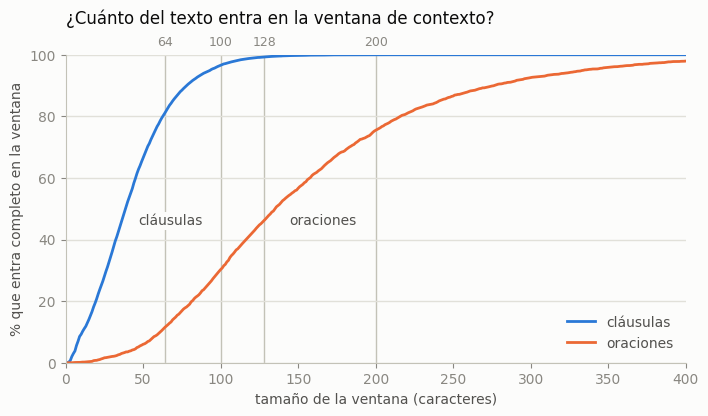

In [10]:
# % de cláusulas / oraciones que entra completo en una ventana de `x` caracteres
x = np.arange(0, 401)
fig, ax = plt.subplots(figsize=(8, 4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

series = [(clause_len, "#2a78d6", "cláusulas"), (sentence_len, "#eb6834", "oraciones")]
for lengths, color, label in series:
    curve = 100 * np.searchsorted(np.sort(lengths), x, side="right") / len(lengths)
    ax.plot(x, curve, color=color, linewidth=2, label=label)
    # etiqueta directa, a la derecha del punto donde la curva llega al 50% (la mediana)
    ax.text(
        np.median(lengths) + 8,
        46,
        label,
        color="#52514e",
        fontsize=10,
        va="center",
        bbox={"facecolor": "#fcfcfb", "edgecolor": "none", "pad": 1.5},
    )

# ventanas candidatas
for w in [64, 100, 128, 200]:
    ax.axvline(w, color="#c3c2b7", linewidth=1, zorder=0)
    ax.text(w, 102, str(w), ha="center", va="bottom", color="#898781", fontsize=9)

ax.set_xlim(0, 400)
ax.set_ylim(0, 100)
ax.set_xlabel("tamaño de la ventana (caracteres)", color="#52514e")
ax.set_ylabel("% que entra completo en la ventana", color="#52514e")
ax.set_title(
    "¿Cuánto del texto entra en la ventana de contexto?", loc="left", pad=22, color="#0b0b0b"
)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#c3c2b7")
ax.legend(frameon=False, loc="lower right", labelcolor="#52514e")
plt.show()

In [11]:
# costo de cada ventana con el armado del dataset de más abajo (ventanas deslizantes de paso 1):
# hay ~1 ventana por caracter de entrenamiento, así que la memoria de X e y y el tiempo por epoch
# crecen linealmente con el tamaño de la ventana
rows = []
for w in candidate_windows:
    n_val_chars = int(np.ceil(len(article_text) * 0.1 / w)) * w  # 10% para validación, como abajo
    n_windows = len(article_text) - n_val_chars - w  # filas de X
    rows.append(
        {
            "ventana (caracteres)": w,
            "ventanas de entrenamiento": n_windows,
            "memoria X + y (MB)": round(2 * n_windows * w * 8 / 1e6),  # arrays int64
            "costo por epoch (100 = 1.0)": w / 100,
        }
    )
pd.DataFrame(rows)

,ventana (caracteres),ventanas de entrenamiento,memoria X + y (MB),costo por epoch (100 = 1.0)
0,50,546033,437,0.50
1,64,545983,559,0.64
2,100,545983,874,1.00
3,128,545855,1118,1.28
4,150,545883,1310,1.50
5,200,545783,1747,2.00
6,256,545599,2235,2.56
7,300,545583,2619,3.00


### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

**Qué muestra el análisis exploratorio**

- **Escala:** una palabra ocupa ~5 caracteres contando separadores, así que 100 caracteres son ~19 palabras.
- **Cláusulas:** miden 39 caracteres de mediana y 79 en el percentil 90. Con una ventana de 100 caracteres entra completo el 97% de las cláusulas y con 128 el 99%: más allá casi no se gana nada.
- **Oraciones:** Butler escribe oraciones largas (mediana de 136 caracteres, unas 26 palabras; p90 de 277). Con 100 caracteres entra completa el 30% de las oraciones, y habría que llegar a ~200 para cubrir el 75%.
- **Costo:** con ventanas deslizantes de paso 1, la memoria de `X` e `y` y el tiempo por epoch crecen linealmente con la ventana (con 200 caracteres es el doble que con 100). Vamos a entrenar tres arquitecturas (SimpleRNN, LSTM y GRU) y las dos últimas son bastante más costosas que la SimpleRNN.
- **Capacidad del modelo:** una RNN simple suele tener dificultades para aprovechar dependencias de cientos de pasos, así que una ventana más larga no necesariamente se traduce en una mejor perplejidad.

**Decisión: `max_context_size = 100`.** Cubre casi todas las cláusulas (97%) con un costo moderado. Usamos el mismo valor para las tres arquitecturas: la perplejidad se calcula con prefijos de hasta `max_context_size` caracteres, así que los modelos sólo son comparables entre sí si tienen el mismo contexto.


In [12]:
# seleccionamos el tamaño de contexto (ver el análisis exploratorio de arriba)
max_context_size = 100

In [13]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences  # se utilizará para padding

In [14]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
# lo ordenamos para que cada caracter tenga siempre el mismo índice: un `set` no garantiza el
# orden entre ejecuciones y el modelo guardado en disco dejaría de coincidir con `char2idx`
chars_vocab = sorted(set(article_text))

In [15]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

42

In [16]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v, k in enumerate(chars_vocab)}
idx2char = {v: k for k, v in char2idx.items()}

# `pad_sequences` rellena con el índice 0. Como el vocabulario está ordenado, el 0 es "\n" (el
# salto de línea entre párrafos): rellenar a la izquierda equivale a "el texto empieza en un
# inicio de párrafo", un caracter que el modelo sí vio en entrenamiento (y no un símbolo nuevo)
assert idx2char[0] == "\n"

### Tokenizar


In [17]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [18]:
tokenized_text[:1000]

[34,
 19,
 26,
 26,
 1,
 27,
 19,
 7,
 1,
 29,
 1,
 27,
 35,
 33,
 19,
 7,
 1,
 29,
 20,
 1,
 34,
 22,
 15,
 34,
 1,
 23,
 28,
 21,
 19,
 28,
 23,
 29,
 35,
 33,
 1,
 22,
 19,
 32,
 29,
 1,
 37,
 22,
 29,
 1,
 34,
 32,
 15,
 36,
 19,
 26,
 26,
 19,
 18,
 1,
 20,
 15,
 32,
 1,
 15,
 28,
 18,
 1,
 37,
 23,
 18,
 19,
 1,
 15,
 20,
 34,
 19,
 32,
 1,
 22,
 19,
 1,
 22,
 15,
 18,
 1,
 33,
 15,
 17,
 25,
 19,
 18,
 1,
 34,
 22,
 19,
 1,
 20,
 15,
 27,
 29,
 35,
 33,
 1,
 34,
 29,
 37,
 28,
 1,
 29,
 20,
 1,
 34,
 32,
 29,
 39,
 9,
 1,
 27,
 15,
 28,
 39,
 1,
 17,
 23,
 34,
 23,
 19,
 33,
 1,
 18,
 23,
 18,
 1,
 22,
 19,
 1,
 36,
 23,
 33,
 23,
 34,
 7,
 1,
 15,
 28,
 18,
 1,
 27,
 15,
 28,
 39,
 1,
 37,
 19,
 32,
 19,
 1,
 34,
 22,
 19,
 1,
 28,
 15,
 34,
 23,
 29,
 28,
 33,
 1,
 37,
 23,
 34,
 22,
 1,
 37,
 22,
 29,
 33,
 19,
 1,
 27,
 15,
 28,
 28,
 19,
 32,
 33,
 1,
 15,
 28,
 18,
 1,
 17,
 35,
 33,
 34,
 29,
 27,
 33,
 1,
 22,
 19,
 1,
 37,
 15,
 33,
 1,
 15,
 17,
 31,
 35,
 15,
 23,
 28

### Organizando y estructurando el dataset


In [19]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

In [20]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[: -num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size :]

In [21]:
# cada secuencia de validación es un bloque consecutivo de `max_context_size` tokens
tokenized_sentences_val = [
    val_text[init * max_context_size : (init + 1) * max_context_size] for init in range(num_val)
]
assert all(len(seq) == max_context_size for seq in tokenized_sentences_val)

In [22]:
tokenized_sentences_train = [
    train_text[init : init + max_context_size]
    for init in range(len(train_text) - max_context_size + 1)
]

In [23]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como _many-to-many_:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como _many-to-one_ en donde sólo una señal de gradiente se propaga.


En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.


In [24]:
X.shape

(545983, 100)

In [25]:
X[0, :10]

array([34, 19, 26, 26,  1, 27, 19,  7,  1, 29])

In [26]:
y[0, :10]

array([19, 26, 26,  1, 27, 19,  7,  1, 29,  1])

In [27]:
vocab_size = len(chars_vocab)

# Definiendo el modelo


In [28]:
from keras.layers import GRU, LSTM, CategoryEncoding, Dense, Input, SimpleRNN, TimeDistributed
from keras.models import Sequential

### Arquitecturas a comparar

Los modelos consumen los índices de los tokens y los transforman en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding`, que transforma a índices a vectores OHE, y `TimeDistributed`, que aplica la capa a lo largo de la dimensión "temporal" de la secuencia. Después vienen la capa recurrente y una capa `Dense` con softmax que devuelve, en cada posición, la distribución de probabilidad del próximo caracter.

Vamos a comparar las tres celdas recurrentes que propone la consigna, **con el mismo tamaño (200 unidades), el mismo dropout, el mismo optimizador (`rmsprop`) y la misma semilla**, de modo que la única diferencia sea la celda:

- **SimpleRNN (celda de Elman):** un único estado oculto que se reescribe en cada paso. Es la más simple y barata, pero el gradiente se desvanece en secuencias largas y le cuesta retener información de pasos lejanos.
- **LSTM:** agrega un estado de celda y tres compuertas (entrada, olvido y salida) que regulan qué se guarda y qué se descarta. Está pensada para conservar dependencias largas; su capa recurrente tiene 4 veces los parámetros de la SimpleRNN (4 matrices de pesos en lugar de 1).
- **GRU:** una versión simplificada de la LSTM, con dos compuertas (actualización y reinicio) y sin estado de celda separado. Su capa recurrente tiene 3 veces los parámetros de la SimpleRNN.


In [ ]:
def build_model(
    rnn_layer, units=200, n_layers=1, dropout=0.1, recurrent_dropout=0.0, optimizer="rmsprop"
):
    # índices -> one-hot -> capas recurrentes -> softmax sobre el próximo caracter en cada posición
    model = Sequential()
    model.add(Input(shape=(None, 1)))
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot")))
    for _ in range(n_layers):
        model.add(
            rnn_layer(
                units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout
            )
        )
    model.add(Dense(vocab_size, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)
    return model


# arquitecturas a comparar
experiments = {
    "simple_rnn": {"label": "SimpleRNN", "kwargs": {"rnn_layer": SimpleRNN}},
    "lstm": {"label": "LSTM", "kwargs": {"rnn_layer": LSTM}},
    "gru": {"label": "GRU", "kwargs": {"rnn_layer": GRU}},
}

# cantidad de parámetros de cada una
pd.DataFrame(
    {
        "arquitectura": [cfg["label"] for cfg in experiments.values()],
        "parámetros": [build_model(**cfg["kwargs"]).count_params() for cfg in experiments.values()],
    }
)

,arquitectura,parámetros
0,SimpleRNN,57042
1,LSTM,202842
2,GRU,154842


### Perplejidad como métrica

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback _ad-hoc_ que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

Respecto del callback original hicimos tres ajustes:

- **Las filas de cada secuencia de validación.** Una secuencia de largo `len_seq` aporta `len_seq - 1` filas (una por cada caracter a predecir), pero el índice avanzaba de a `len_seq`: los últimos grupos quedaban vacíos y puntuaban una perplejidad de 1.0, sesgando el promedio hacia abajo.
- **`history_ppl` y `save_path`.** El callback guarda la lista `history_ppl` que recibe (antes escribía en una variable global del mismo nombre) y el mejor modelo en `save_path`, para que cada arquitectura tenga su propio archivo.
- **La pérdida de entrenamiento** de cada epoch, para poder comparar las curvas después sin reentrenar.


In [31]:
class PplCallback(keras.callbacks.Callback):
    """
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación
    de secuencias. Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs y guarda en `save_path`
    el mejor modelo (el de menor perplejidad de validación).
    """

    def __init__(self, val_data, history_ppl, patience=5, save_path="my_model.keras"):
        # El callback lo inicializamos con secuencias de validación sobre las cuales
        # mediremos la perplejidad
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.history_loss = []  # pérdida de entrenamiento de cada epoch
        self.save_path = str(save_path)

        self.target = []
        self.padded = []

        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience

        # nos movemos en todas las secuencias de los datos de validación
        for seq in self.val_data:
            len_seq = len(seq)
            # armamos todas las subsecuencias
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            if len(subseq) != 0:
                self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding="pre"))

                # cada secuencia aporta `len_seq - 1` filas (una por caracter a predecir)
                self.info.append((count, count + len_seq - 1))
                count += len_seq - 1

        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded, batch_size=512, verbose=0)

        # para cada secuencia de validación
        for start, end in self.info:
            # en `probs` iremos guardando las probabilidades de los términos target
            probs = np.array(
                [
                    predictions[idx_seq, -1, idx_vocab]
                    for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])
                ],
                dtype=np.float64,
            )

            # calculamos la perplejidad por medio de logaritmos
            scores.append(np.exp(-np.sum(np.log(np.maximum(probs, 1e-10))) / (end - start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = float(np.mean(scores))
        self.history_ppl.append(current_score)
        self.history_loss.append(float((logs or {}).get("loss", np.nan)))
        print(f"\n mean perplexity: {current_score} \n")

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.save_path)
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

### Entrenamiento

Cada arquitectura se entrena en su propia celda, con los mismos hiperparámetros (`epochs=20`, `batch_size=256`, `rmsprop`) y la misma semilla. El entrenamiento termina antes si la perplejidad de validación no mejora durante 5 epochs seguidas (_early stopping_).


In [33]:
import json
import sys
import time

# En Google Colab los archivos de la sesión se pierden al desconectarse: se guardan en Drive
if "google.colab" in sys.modules:
    from google.colab import drive

    drive.mount("/content/drive")
    MODELS_DIR = Path("/content/drive/MyDrive/nlp1_models")
else:
    MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
print(f"Los modelos y las curvas se guardan en: {MODELS_DIR.resolve()}")


def train_architecture(name, epochs=20, batch_size=256, patience=5, seed=42):
    """
    Entrena la arquitectura `name` (ver `experiments`) y deja en `MODELS_DIR` su mejor modelo
    y sus curvas de entrenamiento, para poder compararlas después sin volver a entrenar.
    """
    keras.utils.set_random_seed(seed)
    model = build_model(**experiments[name]["kwargs"])

    history_ppl = []
    callback = PplCallback(
        tokenized_sentences_val,
        history_ppl,
        patience=patience,
        save_path=MODELS_DIR / f"{name}.keras",
    )

    start = time.time()
    try:
        model.fit(X, y, epochs=epochs, callbacks=[callback], batch_size=batch_size)
    finally:
        # se guarda aunque el entrenamiento se interrumpa: las epochs ya hechas no se pierden
        history = {
            "name": name,
            "params": model.count_params(),
            "val_ppl": [float(ppl) for ppl in history_ppl],
            "train_loss": [float(loss) for loss in callback.history_loss],
            "seconds": time.time() - start,
            "max_context_size": max_context_size,
            "vocab_size": vocab_size,
        }
        (MODELS_DIR / f"{name}_history.json").write_text(json.dumps(history))
        if history_ppl:
            best = int(np.argmin(history_ppl))
            print(f"Mejor perplejidad de validación: {history_ppl[best]:.3f} (epoch {best + 1})")

Mounted at /content/drive
Los modelos y las curvas se guardan en: /content/drive/MyDrive/nlp1_models


In [34]:
# SimpleRNN (celda de Elman)
train_architecture("simple_rnn")

Epoch 1/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.1713
 mean perplexity: 4.97921135767963 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 46s 18ms/step - loss: 1.9352
Epoch 2/20
2132/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6579
 mean perplexity: 4.383947311013533 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 1.6263
Epoch 3/20
2131/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5613
 mean perplexity: 4.238936688024414 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 1.5487
Epoch 4/20
2132/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5175
 mean perplexity: 4.104745611959664 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 1.5100
Epoch 5/20
2130/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.4912
 mean perplexity: 4.098710841663234 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 1.4865
Epoch 6/20
2131/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.4730
 mean 

In [35]:
# LSTM
train_architecture("lstm")

Epoch 1/20
2131/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.3753
 mean perplexity: 5.748171110409865 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step - loss: 2.1044
Epoch 2/20
2131/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.7914
 mean perplexity: 4.908933426758867 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 1.7505
Epoch 3/20
2131/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.6553
 mean perplexity: 4.670802916436979 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 1.6320
Epoch 4/20
2132/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.5732
 mean perplexity: 4.471749644422482 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 1.5571
Epoch 5/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.5154
 mean perplexity: 4.314678020977736 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 1.5040
Epoch 6/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.4734
 mean

In [36]:
# GRU
train_architecture("gru")

Epoch 1/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.2530
 mean perplexity: 4.728673996989009 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - loss: 1.9616
Epoch 2/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5781
 mean perplexity: 3.9870974637065353 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - loss: 1.5299
Epoch 3/20
2131/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.4307
 mean perplexity: 3.8059595602731005 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - loss: 1.4105
Epoch 4/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.3629
 mean perplexity: 3.7717374735193188 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - loss: 1.3513
Epoch 5/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.3223
 mean perplexity: 3.7518438310363846 

Saved new model!
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - loss: 1.3148
Epoch 6/20
2132/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.2945
 

### Comparación de arquitecturas


In [37]:
results = {}
for name in experiments:
    path = MODELS_DIR / f"{name}_history.json"
    if not path.exists():
        print(f"Falta {path}: entrenar '{name}' antes de comparar")
        continue

    res = json.loads(path.read_text())
    if not res["val_ppl"]:
        print(f"{path} no tiene ninguna epoch completa: entrenar '{name}' de nuevo")
        continue
    # curvas de otra configuración (otro vocabulario o tamaño de contexto) no son comparables
    assert res["vocab_size"] == vocab_size and res["max_context_size"] == max_context_size, (
        f"{path} se entrenó con otro vocabulario o tamaño de contexto: entrenar '{name}' de nuevo"
    )
    results[name] = res

rows = []
for name, res in results.items():
    best_epoch = int(np.argmin(res["val_ppl"])) + 1
    rows.append(
        {
            "arquitectura": experiments[name]["label"],
            "parámetros": res["params"],
            "mejor ppl de validación": min(res["val_ppl"]),
            "mejor epoch": best_epoch,
            "epochs corridas": len(res["val_ppl"]),
            "ppl de entrenamiento (en esa epoch)": np.exp(res["train_loss"][best_epoch - 1]),
            "minutos por epoch": res["seconds"] / 60 / len(res["val_ppl"]),
        }
    )
summary = pd.DataFrame(rows).set_index("arquitectura").round(2)
summary

,parámetros,mejor ppl de validación,mejor epoch,epochs corridas,ppl de entrenamiento (en esa epoch),minutos por epoch
arquitectura,,,,,,
SimpleRNN,57042,3.94,19,20,4.10,0.55
LSTM,202842,3.80,19,20,3.62,0.89
GRU,154842,3.75,5,10,3.72,0.81


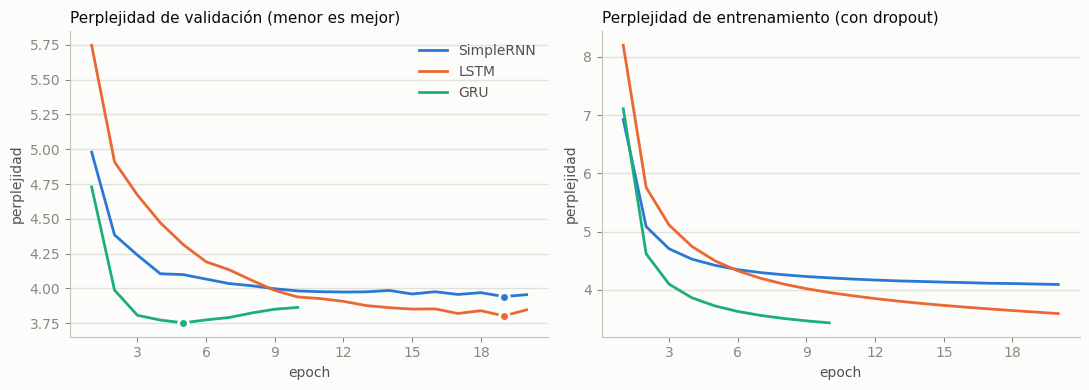

In [38]:
from matplotlib.ticker import MaxNLocator

# paleta categórica en orden fijo: cada arquitectura conserva su color en todos los gráficos
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
assert len(experiments) <= len(SERIES_COLORS), "hay más arquitecturas que colores"
colors = dict(zip(experiments, SERIES_COLORS))


def style_axes(ax, title, xlabel, ylabel):
    ax.set_facecolor("#fcfcfb")
    ax.set_title(title, loc="left", color="#0b0b0b", fontsize=11)
    ax.set_xlabel(xlabel, color="#52514e")
    ax.set_ylabel(ylabel, color="#52514e")
    ax.grid(axis="y", color="#e1e0d9", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#898781")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color("#c3c2b7")


fig, (ax_val, ax_train) = plt.subplots(1, 2, figsize=(11, 4), facecolor="#fcfcfb")
for name, res in results.items():
    label = experiments[name]["label"]
    epochs_axis = np.arange(1, len(res["val_ppl"]) + 1)
    ax_val.plot(epochs_axis, res["val_ppl"], color=colors[name], linewidth=2, label=label)
    ax_train.plot(
        epochs_axis, np.exp(res["train_loss"]), color=colors[name], linewidth=2, label=label
    )
    # punto en la mejor epoch (la que guarda el modelo)
    best = int(np.argmin(res["val_ppl"]))
    ax_val.plot(
        best + 1,
        res["val_ppl"][best],
        "o",
        color=colors[name],
        markersize=7,
        markeredgecolor="#fcfcfb",
        markeredgewidth=2,
    )

style_axes(ax_val, "Perplejidad de validación (menor es mejor)", "epoch", "perplejidad")
style_axes(ax_train, "Perplejidad de entrenamiento (con dropout)", "epoch", "perplejidad")
for ax in (ax_val, ax_train):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_val.legend(frameon=False, labelcolor="#52514e")
plt.tight_layout()
plt.show()

**Interpretación**

- La arquitectura GRU alcanza la menor perplejidad en muchas menos epochs en comparación con una RNN y LSTM. Las otras arquitecturas llegaron a su mejor perplejidad cerca del limite de 20 epocas, resultando en GRU el mejor modelo y más eficiente en cuanto a entrenamiento. RNN terminó siendo el peor modelo.

- GRU llegó a su mejor perplejidad en la epoch 5 antes de detenerse por early stopping en la epoch 10 donde ya estaba ocurriendo overfitting debido a que la perplejidad de entrenamiento seguía bajando mientras que la de val subía.

- GRU terminó siendo el mejor modelo pero no por mucho, la diferencia de los valores de perplejidad de train y val no son muy distantes con los de RNN y LSTM. Además, al tener más parametros el tiempo de entrenamiento es superior. También, su mejor valor fue mucho más rápido (5 epochs).


In [39]:
def load_trained(name):
    # carga el mejor modelo guardado de la arquitectura `name` (sólo para inferencia: sin compilar)
    trained = keras.models.load_model(str(MODELS_DIR / f"{name}.keras"), compile=False)
    # un modelo guardado con otro vocabulario (p. ej. de una corrida anterior) no sirve
    assert trained.layers[-1].units == vocab_size, f"{name}.keras no coincide con el vocabulario"
    return trained


# Cargamos el mejor modelo (menor perplejidad de validación) para hacer inferencia
best_name = min(results, key=lambda name: min(results[name]["val_ppl"]))
model = load_trained(best_name)
print(f"Modelo elegido: {experiments[best_name]['label']}")

Modelo elegido: GRU


### Predicción del próximo caracter

El modelo devuelve, para cada posición, una distribución de probabilidad sobre el próximo caracter. Veamos las 5 opciones más probables para algunos contextos (`'\n'` es el salto de línea entre párrafos).


In [40]:
# funcionalidades para hacer encoding y decoding


def encode(text, max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding="pre")

    return encoded


def decode(seq):
    return "".join([idx2char[ch] for ch in seq])


def next_char_probs(model, text):
    # distribución de probabilidad del modelo sobre el próximo caracter
    return model.predict_on_batch(encode(text.lower()))[0, -1, :]


contexts = ["ulysses answered, ", "the suitors were ", "telemachus said to his mother, "]
top_chars = {}
for context in contexts:
    probs = next_char_probs(model, context)
    top = np.argsort(probs)[::-1][:5]
    top_chars[repr(context)] = [f"{idx2char[i]!r} {probs[i]:.2f}" for i in top]
pd.DataFrame(top_chars, index=[f"top {rank}" for rank in range(1, 6)])

,"'ulysses answered, '",'the suitors were ',"'telemachus said to his mother, '"
top 1,"'""' 0.75",'t' 0.17,'a' 0.32
top 2,"""'"" 0.17",'a' 0.13,'w' 0.13
top 3,'a' 0.01,'b' 0.10,'t' 0.08
top 4,'w' 0.01,'i' 0.08,'b' 0.08
top 5,'i' 0.01,'o' 0.06,'f' 0.08


In [42]:
# Demo interactiva (opcional) con gradio: https://gradio.app/
# Está apagada por defecto: en Google Colab gradio crea un link público (gradio.live) para la demo.
# Para usarla hay que instalar gradio (`uv add gradio` en local) y poner RUN_GRADIO_DEMO = True
RUN_GRADIO_DEMO = True

if RUN_GRADIO_DEMO:
    import gradio as gr

    def model_response(human_text):
        # Predicción softmax: el caracter más probable
        y_hat = np.argmax(next_char_probs(model, human_text))
        # Agrego el caracter a la frase predicha
        return human_text + idx2char[y_hat]

    iface = gr.Interface(fn=model_response, inputs=["textbox"], outputs="text")
    iface.launch()  # sin debug=True: no bloquea la ejecución del notebook

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e9f009cdc8527a3253.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Generación de secuencias

Partiendo de un contexto (_seed_), el modelo genera texto de a un caracter: predice la distribución del próximo caracter, elige uno, lo agrega al contexto y repite. Lo que cambia entre estrategias es **cómo se elige**:

- **Greedy search:** toma siempre el caracter más probable. Es determinístico y rápido, pero miope: un caracter localmente óptimo puede llevar a una secuencia poco probable en conjunto, y suele caer en repeticiones.
- **Beam search determinístico:** mantiene en paralelo las `num_beams` secuencias candidatas más probables. En cada paso expande cada una con todos los caracteres posibles y se queda con las `num_beams` de mayor **log-probabilidad acumulada**. Suele encontrar secuencias más probables que greedy (no está garantizado), a un costo `num_beams` veces mayor.
- **Beam search estocástico:** en lugar de quedarse con los mejores candidatos, **muestrea** `num_beams` de ellos con probabilidad `softmax(log-probabilidad acumulada / T)`. La temperatura `T` controla cuánta aleatoriedad se introduce:
  - `T → 0` concentra toda la probabilidad en el mejor candidato: los beams terminan siendo copias y la búsqueda se vuelve **greedy**.
  - `T = 1` muestrea según las probabilidades del modelo.
  - `T > 1` aplana la distribución: más diversidad, pero también más errores (palabras inexistentes, signos mal cerrados).

  Con un solo beam es el muestreo con temperatura clásico. Con varios beams la temperatura se aplica sobre la log-probabilidad **acumulada** de la secuencia completa y no sólo sobre el último caracter, así que a igual `T` el efecto no es el mismo; por eso más abajo se comparan ambos casos.

Los contextos que usamos tienen menos de `max_context_size` caracteres, terminan en un espacio y sólo tienen caracteres del vocabulario (`encode` no pasa a minúsculas ni conoce caracteres que no estén en el corpus).


In [43]:
def generate_seq(model, seed_text, max_length, n_words):
    """
    Exec model sequence prediction

    Args:
        model (keras): modelo entrenado
        seed_text (string): texto de entrada (input_seq)
        max_length (int): máxima longitud de la sequencia de entrada
        n_words (int): números de caracteres a agregar a la sequencia de entrada
    returns:
        output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
    # generate a fixed number of words
    for _ in range(n_words):
        # Encodeamos (si tienen distinto largo se completa con padding)
        encoded = encode(output_text.lower(), max_length)

        # Predicción softmax
        y_hat = np.argmax(model.predict_on_batch(encoded)[0, -1, :])

        # Vamos concatenando las predicciones
        output_text += idx2char[y_hat]
    return output_text

In [44]:
from scipy.special import softmax


# función que selecciona candidatos para el beam search
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):

    # colectar todas las probabilidades para la siguiente búsqueda
    pred_large = []

    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])

    pred_large = np.array(pred_large, dtype=np.float64)

    # criterio de selección
    if mode == "det":
        idx_select = np.argsort(pred_large)[::-1][:num_beams]  # beam search determinista
    elif mode == "sto":
        if temp <= 0:
            raise ValueError(f"La temperatura debe ser positiva. {temp} was given.")
        idx_select = np.random.choice(
            np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large / temp)
        )  # beam search con muestreo aleatorio
    else:
        raise ValueError(f"Wrong selection mode. {mode} was given. det and sto are supported.")

    # traducir a índices de token en el vocabulario
    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size], np.array([idx_select % vocab_size]).T),
        axis=1,
    )

    # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, mode="det", return_scores=False):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict_on_batch(encoded)[0, -1, :]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode
    )

    # beam search loop
    for i in range(num_words - 1):
        # actualizar la secuencia de tokens de todos los beams y predecir todos juntos (un batch)
        input_update = np.array([hist[i + 1 :] for hist in history_tokens])
        preds = model.predict_on_batch(input_update)[:, -1, :]

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )

    tokens = history_tokens[:, -(len(input) + num_words) :]

    # opcionalmente se devuelve también la log-probabilidad acumulada de cada beam
    return (tokens, history_probs) if return_scores else tokens

Para comparar las estrategias medimos tres cosas sobre el texto generado (sin contar el contexto):

- **Perplejidad:** qué tan probable es el texto para el propio modelo (menor = más probable). Cada caracter se puntúa con los `max_context_size` caracteres anteriores, igual que al generar.
- **% de palabras del corpus:** qué porcentaje de las palabras completas generadas existen en el corpus. Es una forma de medir si el modelo por caracteres "escribe bien" (se descarta la última palabra, que puede haber quedado cortada).
- **% de palabras distintas:** diversidad del texto. Un valor bajo indica texto repetitivo.


In [45]:
import textwrap

corpus_words = set(re.findall(r"[a-z]+(?:'[a-z]+)?", article_text))


def generated_perplexity(model, seed_text, generated_text):
    # perplejidad del texto generado según el modelo: cada caracter se puntúa con los
    # `max_context_size` caracteres anteriores, igual que al generar
    full = [char2idx[ch] for ch in seed_text + generated_text]
    start = len(seed_text)
    contexts = pad_sequences(
        [full[max(0, i - max_context_size) : i] for i in range(start, len(full))],
        maxlen=max_context_size,
        padding="pre",
    )
    probs = model.predict_on_batch(contexts)[:, -1, :]
    probs_target = probs[np.arange(len(contexts)), full[start:]]
    return float(np.exp(-np.mean(np.log(np.maximum(probs_target, 1e-10)))))


def text_quality(model, seed_text, generated_text):
    # palabras completas generadas (se descarta la última, que puede haber quedado cortada)
    words_generated = re.findall(r"[a-z]+(?:'[a-z]+)?", generated_text)[:-1]
    if not words_generated:
        return {
            "perplejidad": np.nan,
            "% palabras del corpus": np.nan,
            "% palabras distintas": np.nan,
        }
    return {
        "perplejidad": generated_perplexity(model, seed_text, generated_text),
        "% palabras del corpus": 100 * np.mean([w in corpus_words for w in words_generated]),
        "% palabras distintas": 100 * len(set(words_generated)) / len(words_generated),
    }


def show(text, width=100):
    print(textwrap.fill(text.replace("\n", " ⏎ "), width=width))

### Greedy search vs beam search determinístico


In [46]:
# contextos de partida: terminan en un espacio para que el modelo empiece una palabra nueva
seeds = ["ulysses answered, ", "the suitors were "]
n_chars = 150  # cantidad de caracteres a generar

rows = []
for seed in seeds:
    greedy = generate_seq(model, seed, max_length=max_context_size, n_words=n_chars)
    tokens = beam_search(model, num_beams=10, num_words=n_chars, input=seed, mode="det")
    beam = decode(tokens[0])  # en modo determinístico el primer beam es el de mayor probabilidad

    for strategy, text in [("greedy", greedy), ("beam search (10 beams)", beam)]:
        print(f"[{strategy}]")
        show(text)
        quality = text_quality(model, seed, text[len(seed) :])
        rows.append({"contexto": seed, "estrategia": strategy, **quality})
    print()

pd.DataFrame(rows).round(2)

[greedy]
ulysses answered, "i will tell you a seat and drink offerings to the sea shore, and the suitors were
to the house of hades and sent the sea shore, and the suitors were
[beam search (10 beams)]
ulysses answered, "stranger," said telemachus," said telemachus," said telemachus," said
telemachus," said telemachus," said telemachus," said telemachus, "telemachus,

[greedy]
the suitors were the first to the store room and show distress of the sea shore, and the suitors
were to the house of hades and sent the sea shore, and the suitors wer
[beam search (10 beams)]
the suitors were close to the house of king alcinous, who will give you to the house of king
alcinous, who will give you to the house of king alcinous, who will give y



,contexto,estrategia,perplejidad,% palabras del corpus,% palabras distintas
0,"ulysses answered,",greedy,1.73,100.0,63.33
1,"ulysses answered,",beam search (10 beams),1.40,100.0,20.00
2,the suitors were,greedy,1.82,100.0,53.33
3,the suitors were,beam search (10 beams),1.54,100.0,36.67


**Interpretación**

- Podemos ver que greedy, a pesar de que el texto que genera no tiene mucho sentido, es más rico que beam search, que rápidamente repite su generación de texto (20% y 37% de palabras distintas contra 63% y 53%; greedy también repite algo, pero más tarde). Beam search es mejor optimizando la probabilidad y para este modelo el texto más probable es el repetitivo, por eso tiene la menor perplejidad (1.40 y 1.54 contra 1.73 y 1.82): un texto repetitivo es muy predecible, así que menor perplejidad acá no significa mejor texto.

- El 100% de las palabras generadas existe en el corpus, así que ni greedy ni beam search inventan palabras. Los errores son otros: frases con palabras reales pero sin sentido (_"a seat and drink offerings to the sea shore"_) y comillas que beam search abre y cierra sin lógica.


### ¿Cambia el texto según la arquitectura?

Mismo contexto y misma estrategia (greedy) para cada modelo entrenado. No comparamos la perplejidad del texto porque cada modelo puntuaría su propia salida.


In [47]:
rows = []
for name in results:
    trained = load_trained(name)
    text = generate_seq(trained, seeds[0], max_length=max_context_size, n_words=n_chars)
    print(f"[{experiments[name]['label']}]")
    show(text)
    print()

    quality = text_quality(trained, seeds[0], text[len(seeds[0]) :])
    quality.pop("perplejidad")
    rows.append({"arquitectura": experiments[name]["label"], **quality})

pd.DataFrame(rows).round(2)

[SimpleRNN]
ulysses answered, "i had been got to the house of the house of the house of the house of the house
of the house of the house of the house of the house of the house of t

[LSTM]
ulysses answered, "i will tell you all the other suitors who is not to be a children of the suitors
to the suitors and the suitors were to be a long way off the house o

[GRU]
ulysses answered, "i will tell you a seat and drink offerings to the sea shore, and the suitors were
to the house of hades and sent the sea shore, and the suitors were



,arquitectura,% palabras del corpus,% palabras distintas
0,SimpleRNN,100.0,22.86
1,LSTM,100.0,66.67
2,GRU,100.0,63.33


### Beam search estocástico: efecto de la temperatura

Generamos desde el mismo contexto variando la temperatura `T`, con **1 beam** (muestreo con temperatura clásico) y con **10 beams**. Como el muestreo es aleatorio repetimos cada configuración 5 veces y promediamos las métricas; se fija la semilla de numpy para que el experimento sea reproducible.

Elegimos un rango amplio de temperaturas (de 0.5 a 5) porque, como la temperatura se aplica a la log-probabilidad acumulada, no sabemos de antemano a partir de qué valor se nota el efecto con varios beams.


In [48]:
temperatures = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
n_runs = 5
seed = seeds[0]

np.random.seed(0)  # reproducibilidad del muestreo
rows, examples = [], {}
for num_beams in [1, 10]:
    for temp in temperatures:
        runs = []
        for run in range(n_runs):
            tokens = beam_search(
                model, num_beams=num_beams, num_words=n_chars, input=seed, temp=temp, mode="sto"
            )
            text = decode(tokens[0])  # en modo estocástico el orden de los beams es aleatorio
            runs.append(text_quality(model, seed, text[len(seed) :]))
            if run == 0:
                examples[(num_beams, temp)] = text
        rows.append({"beams": num_beams, "temperatura": temp, **pd.DataFrame(runs).mean()})

temp_results = pd.DataFrame(rows)
temp_results.round(2)

,beams,temperatura,perplejidad,% palabras del corpus,% palabras distintas
0,1,0.5,2.21,96.41,76.75
1,1,1.0,3.52,85.30,88.03
2,1,1.5,6.61,55.45,96.78
3,1,2.0,12.55,35.31,98.31
4,1,3.0,73.09,13.74,99.26
5,1,5.0,461.52,11.11,97.42
6,10,0.5,1.70,100.00,68.19
7,10,1.0,1.72,100.00,69.29
8,10,1.5,1.96,100.00,67.75
9,10,2.0,2.21,98.03,78.09


In [49]:
# un ejemplo de cada configuración
for (num_beams, temp), text in examples.items():
    print(f"[{num_beams} beam{'s' if num_beams > 1 else ''}, T={temp}]")
    show(text)
    print()

[1 beam, T=0.5]
ulysses answered, "stranger, i was to the gods have been sent the gods, and the sea shore with a
care of a well in all sorts of his shoulders, and she had looked the sw

[1 beam, T=1.0]
ulysses answered, "my frich that your own seas. for a man of groan oceanus; when we could make us
many holding to the tobst and women? grasping one of us to the north o

[1 beam, T=1.5]
ulysses answered, "tellesson diered' you, stater you, out my eres. thyed ulysses might helfe, and
tooving yetrieajusian, wresching hisge; but towers wa goifin in turboa

[1 beam, T=2.0]
ulysses answered, you hugos. moreorwal, ulviriturkmilino wible:s hospose ptntlown yis leqays,
clyined you gradglys en abomy wrid; for yel, ampfiures of deevenior mails,

[1 beam, T=3.0]
ulysses answered, appst,' do!n, farwiewarlys astioa] of goldn[-omieicelyfeprif:it,'jumpibilaug
hitrat?' 'rwjrsnzs,'ibagqo—ninhy'bodwae)htcur mn. jagagns sout! teatukisg

[1 beam, T=5.0]
ulysses answered, uftxeved—y?u.—twie]dmq:fh]h., wen)ea

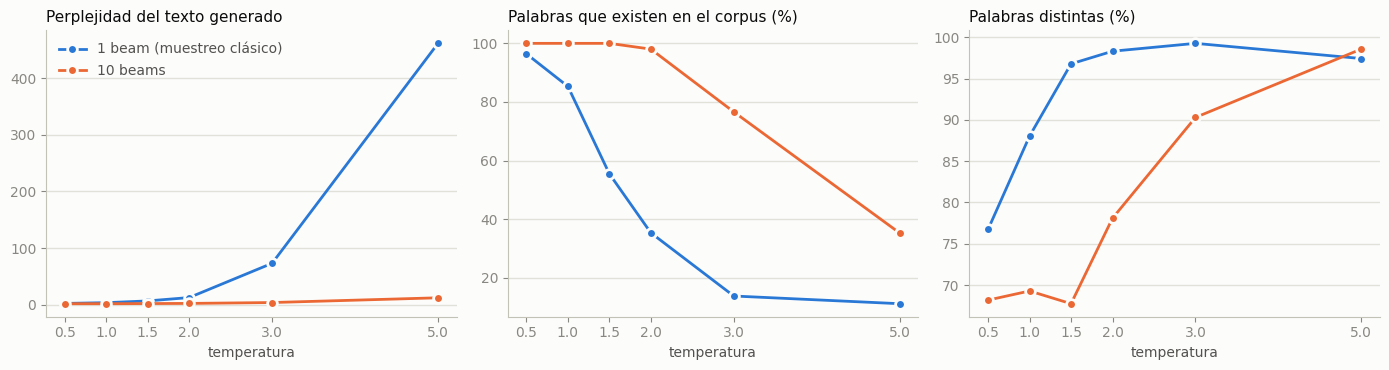

In [50]:
metrics_to_plot = [
    ("perplejidad", "Perplejidad del texto generado"),
    ("% palabras del corpus", "Palabras que existen en el corpus (%)"),
    ("% palabras distintas", "Palabras distintas (%)"),
]
beam_colors = {1: SERIES_COLORS[0], 10: SERIES_COLORS[1]}
beam_labels = {1: "1 beam (muestreo clásico)", 10: "10 beams"}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), facecolor="#fcfcfb")
for ax, (column, title) in zip(axes, metrics_to_plot):
    for num_beams, group in temp_results.groupby("beams"):
        ax.plot(
            group["temperatura"],
            group[column],
            "o-",
            color=beam_colors[num_beams],
            linewidth=2,
            markersize=7,
            markeredgecolor="#fcfcfb",
            markeredgewidth=2,
            label=beam_labels[num_beams],
        )
    style_axes(ax, title, "temperatura", "")
    ax.set_xticks(temperatures)
axes[0].legend(frameon=False, labelcolor="#52514e")
plt.tight_layout()
plt.show()

**Interpretación**

- Podemos ver que al subir T la temperatura aplana la distribución: el modelo le da más chances a caracteres poco probables, así que hay más variedad pero también más errores. Con 1 beam la perplejidad del texto generado pasa de 2.2 (T=0.5) a 461 (T=5), el porcentaje de palabras del corpus cae de 96% a 11% y la diversidad sube a casi 100%, pero ya es diversidad de palabras inventadas. Con T=1 ya hay 15% de palabras inventadas, con T=1.5 casi la mitad, y desde T=2 es mayormente sinsentido.
- Con 10 beams, a igual T el texto es mucho menos aleatorio: menor perplejidad, casi 100% de palabras válidas hasta T=2 y menos diversidad (68–69% contra 77–97% con 1 beam en T=0.5 a 1.5). De hecho 10 beams con T=2 da prácticamente lo mismo que 1 beam con T=0.5 (perplejidad 2.21 en los dos), y 10 beams con T=5 se parece a 1 beam con T=2: hace falta una T unas 3 veces mayor. Se confirma entonces que la temperatura actúa distinto: con varios beams se acumula la log-probabilidad y la selección empuja hacia las secuencias más probables, lo que diluye el efecto de T.

- Depende de qué miremos. En diversidad y perplejidad lo más parecido a la Odisea es 1 beam con T=1 (88% de palabras distintas y perplejidad 3.5, contra ~3.7 de validación), pero con 15% de palabras inventadas. Si priorizamos palabras reales, 10 beams con T=2 o 1 beam con T=0.5 (96–98% válidas, ~77% distintas) son un buen compromiso: texto legible, aunque algo más repetitivo que el real. Greedy y beam search determinístico quedan lejos (20–63% de palabras distintas).
